# EffTemp-Net — SingleFrame Spatial-Only NoLS — One Seed per Colab Session

Notebook ini menjalankan **true single-frame / spatial-only baseline** untuk EffTemp-Net.

Arsitektur:
**1 fixed middle frame → shared EfficientFormerV2-S0 → classifier**

Tidak ada:
- BiLSTM;
- TSM;
- temporal attention;
- mean/max/sum pooling antar-frame;
- inter-frame interaction dalam bentuk apa pun.

Untuk menjaga controlled comparison dengan FrameMean dan varian BiLSTM, notebook memakai **cache 16 frame yang sama**, tetapi hanya mengambil **satu frame tetap** sebelum backbone. Karena `T=16` memiliki dua sampel tengah, digunakan *earlier middle sample* dengan indeks `floor((T-1)/2)=7` (0-based; frame ke-8 dari 16). Aturan ini ditetapkan **a priori**, identik untuk train/validation/test, dan tidak dituning pada hasil validasi/test.

Notebook ini menjalankan **satu training seed per Colab session** agar seed 0, 42, dan 123 dapat dijalankan secara paralel. Default `RUN_SEED=42`.

Untuk menjalankan seed lain secara terpisah, hanya ubah `RUN_SEED` pada sel konfigurasi menjadi `0`, `42`, atau `123`. `FIXED_SPLIT_SEED` harus tetap `42` agar identitas train/validation sama untuk seluruh seed.

Label smoothing dinonaktifkan (`LABEL_SMOOTHING = 0.0`) dan loss adalah standard cross-entropy.

Output utama:
- `history.csv`, training curves, best/last checkpoint;
- prediction CSV per dataset;
- Accuracy, Macro Precision/Recall/F1, per-class metrics, ROC-AUC, AP;
- confusion matrix dan ROC curve;
- bootstrap confidence interval;
- ringkasan metrik untuk seed yang sedang dijalankan;
- parameter count, MACs, dan latency benchmark.


In [1]:

# Instalasi dependensi. Jalankan sekali pada awal sesi Colab.
!pip -q install timm ptflops


In [2]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:

import os
import json
import math
import time
import random
import shutil
import platform
import warnings
from contextlib import nullcontext
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.transforms import functional as TF
from torchvision.transforms import RandomResizedCrop, InterpolationMode

import timm
from timm import create_model
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
)

warnings.filterwarnings("ignore", category=UserWarning)

print("Python :", platform.python_version())
print("PyTorch:", torch.__version__)
print("timm   :", timm.__version__)
print("CUDA   :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))


Python : 3.12.13
PyTorch: 2.11.0+cu128
timm   : 1.0.28
CUDA   : True
GPU    : NVIDIA A100-SXM4-40GB


## 1. Konfigurasi dan definisi spatial-only baseline

Untuk menjalankan secara paralel, **cukup ubah `RUN_SEED`** pada sel konfigurasi. Path `OUTPUT_DIR` otomatis berubah mengikuti seed, sehingga seed berbeda tidak saling menimpa output.

`FIXED_SPLIT_SEED=42` **jangan diubah**, karena seed tersebut mengunci identitas train/validation agar perbandingan antar-training seed tetap fair.

Notebook menggunakan **cache 16 frame yang sama dengan FrameMean/TempSum**, sehingga split, decoding, resolusi mentah, normalisasi, dan sumber video tetap terkontrol.

Definisi baseline:
- cache per video: 16 frame uniform;
- input model: **1 frame saja**;
- frame selection: deterministic middle sample;
- tidak ada akses ke frame lain di dalam model;
- tidak ada temporal aggregation atau temporal module.

Struktur raw-video fallback yang diharapkan:

```text
DATA_ROOT/
├── TrainVal/
│   └── Gabung/
│       ├── NonViolence/
│       └── Violence/
└── Testing/
    ├── HockeyFight/
    ├── MovieFight/
    ├── ViolentFlow/
    ├── Automatic/
    ├── SurveilFight/
    └── Realife/
```


## Cara menjalankan seed 0, 42, dan 123 secara paralel

Duplikasi notebook ini ke tiga Colab session. **Hanya satu baris yang perlu diubah:**

```python
RUN_SEED = 42
```

Gunakan:
- session 1 → `RUN_SEED = 0`
- session 2 → `RUN_SEED = 42`
- session 3 → `RUN_SEED = 123`

Jangan mengubah:
```python
FIXED_SPLIT_SEED = 42
SINGLE_FRAME_INDEX = (SEQUENCE_LENGTH - 1) // 2
```

`OUTPUT_DIR` otomatis menjadi folder berbeda (`...Seed0_v1`, `...Seed42_v1`, `...Seed123_v1`), sehingga aman untuk eksekusi paralel di Google Drive.


In [4]:

# =========================
# PATH — EDIT BAGIAN INI
# =========================
# ============================================================
# HANYA UBAH NILAI INI untuk menjalankan seed lain secara paralel.
# Pilihan eksperimen utama: 0, 42, atau 123.
# ============================================================
RUN_SEED = 0

DATA_ROOT = Path("/content/drive/MyDrive/IVS/ViolenceDataset/EffTempNet_Data")
CACHE_DIR = Path("/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset")
# Folder root dibuat berbeda untuk setiap seed agar beberapa Colab session
# tidak menulis file agregat/ZIP ke lokasi yang sama.
OUTPUT_DIR = Path(
    f"/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/"
    f"EffTempNet_SingleFrame_SpatialOnly_NoLS_Seed{RUN_SEED}_v1"
)

TRAINVAL_DIR = DATA_ROOT / "TrainVal" / "Gabung"

# Lokasi video mentah RWF (dipakai hanya bila cache belum ada)
RWF_RAW_DIR = Path("/content/drive/MyDrive/IVS/ViolenceDataset/Benchmark/RWF")

TEST_SPECS = {
    "HF":   {"raw_dir": DATA_ROOT / "Testing" / "HockeyFight",  "cache_name": "HockeyFight"},
    "MF":   {"raw_dir": DATA_ROOT / "Testing" / "MovieFight",   "cache_name": "MovieFight"},
    "VCF":  {"raw_dir": DATA_ROOT / "Testing" / "ViolentFlow", "cache_name": "ViolentFlow"},
    "AVDV": {"raw_dir": DATA_ROOT / "Testing" / "Automatic",   "cache_name": "Automatic"},
    "SCFD": {"raw_dir": DATA_ROOT / "Testing" / "SurveilFight","cache_name": "Surveilence"},
    "RLVS": {"raw_dir": DATA_ROOT / "Testing" / "Realife",     "cache_name": "Realife"},
    "RWF":  {"raw_dir": RWF_RAW_DIR,                           "cache_name": "RWF"},
}

# RWF adalah domain HELD-OUT: dievaluasi terpisah, TIDAK masuk ALL_TESTS_POOLED,
# agar pooled tetap 411 klip dan sebanding dengan seluruh eksperimen sebelumnya.
POOLED_DATASETS = ["HF", "MF", "VCF", "AVDV", "SCFD", "RLVS"]

# =========================
# EKSPERIMEN WAJIB
# =========================
# Jangan edit SEEDS secara langsung. Ubah RUN_SEED di bagian atas saja.
SEEDS = [RUN_SEED]
REQUIRED_VARIANTS = ["single_frame"]

# Smoke test untuk mengecek pipeline. Ubah False sebelum eksperimen final.
SMOKE_TEST = False

# =========================
# DATA DAN MODEL
# =========================
CLASS_NAMES = ["NonViolence", "Violence"]
NUM_CLASSES = 2
SEQUENCE_LENGTH = 16  # jumlah frame di CACHE, sama dengan eksperimen temporal
MODEL_INPUT_FRAMES = 1

# TRUE SPATIAL-ONLY FRAME POLICY:
# T=16 memiliki dua kandidat tengah (index 7 dan 8). Agar deterministic dan
# tidak melakukan tuning berdasarkan validation/test, tie dipecahkan a priori
# ke frame tengah yang lebih awal: floor((T-1)/2) = 7.
SINGLE_FRAME_INDEX = (SEQUENCE_LENGTH - 1) // 2
SINGLE_FRAME_NUMBER_1BASED = SINGLE_FRAME_INDEX + 1
SINGLE_FRAME_NOMINAL_FRACTION = SINGLE_FRAME_INDEX / (SEQUENCE_LENGTH - 1)

RAW_HEIGHT = 64
RAW_WIDTH = 64
BACKBONE_INPUT_SIZE = 224

VAL_RATIO = 0.11
FIXED_SPLIT_SEED = 42

# Cache lama yang dibuat oleh OpenCV menyimpan BGR.
PREFER_LEGACY_CACHE = True
LEGACY_CACHE_COLOR_ORDER = "BGR"
AUTO_SCALE_LEGACY_CACHE = True  # otomatis 0–255 -> 0–1 bila diperlukan

# =========================
# TRAINING
# =========================
MAX_EPOCHS = 50
EARLY_STOP_PATIENCE = 15
SCHEDULER_PATIENCE = 3
SCHEDULER_FACTOR = 0.6

MICRO_BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 2          # effective batch size = 8
EFFECTIVE_BATCH_SIZE = MICRO_BATCH_SIZE * GRAD_ACCUM_STEPS

LR_BACKBONE = 1e-5
LR_HEAD = 1e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.0
GRAD_CLIP_NORM = 5.0

NUM_WORKERS = 2
USE_AMP = False  # FP32 aman; aktifkan BF16 hanya setelah smoke test berhasil
SKIP_COMPLETED_RUNS = True
RESUME_INTERRUPTED_RUNS = True

# =========================
# AUGMENTATION TRAINING
# Seluruh parameter spasial/fotometrik sama untuk semua frame dalam satu clip.
# =========================
AUGMENTATION = {
    "horizontal_flip_p": 0.5,
    "crop_scale": (0.85, 1.0),
    "crop_ratio": (0.90, 1.10),
    "brightness": 0.12,
    "contrast": 0.12,
    "saturation": 0.08,
}

# =========================
# EVALUASI
# =========================
BOOTSTRAP_SAMPLES = 1000
LATENCY_WARMUP = 50
LATENCY_RUNS = 200

if SMOKE_TEST:
    # Smoke test tetap hanya memakai seed yang dipilih pada RUN_SEED.
    SEEDS = [RUN_SEED]
    MAX_EPOCHS = 2
    EARLY_STOP_PATIENCE = 2
    BOOTSTRAP_SAMPLES = 100
    print("⚠️ SMOKE_TEST aktif: hasil tidak boleh dipakai di paper.")

if RUN_SEED not in [0, 42, 123]:
    raise ValueError(
        f"RUN_SEED={RUN_SEED} tidak termasuk seed eksperimen utama [0, 42, 123]."
    )

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("Training seed :", RUN_SEED)
print("Fixed split seed:", FIXED_SPLIT_SEED, "(JANGAN DIUBAH antar-training seed)")
print("Required runs :", len(SEEDS) * len(REQUIRED_VARIANTS))
print("Effective batch size:", EFFECTIVE_BATCH_SIZE)
print("Output directory:", OUTPUT_DIR)
print(
    f"Single-frame policy: cache index={SINGLE_FRAME_INDEX} "
    f"(frame {SINGLE_FRAME_NUMBER_1BASED}/{SEQUENCE_LENGTH}), "
    f"nominal temporal position={SINGLE_FRAME_NOMINAL_FRACTION:.3f}"
)


Training seed : 0
Fixed split seed: 42 (JANGAN DIUBAH antar-training seed)
Required runs : 1
Effective batch size: 8
Output directory: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_SingleFrame_SpatialOnly_NoLS_Seed0_v1
Single-frame policy: cache index=7 (frame 8/16), nominal temporal position=0.467


In [5]:
import json
from pathlib import Path

variant = "single_frame"
print(f"\n=== {variant} ===")

for s in SEEDS:
    d = OUTPUT_DIR / variant / f"seed_{s}"
    done = (d / "completed.json").exists() and (d / "test_metrics.csv").exists()
    partial = (d / "last.pt").exists() and not done
    status = "SELESAI" if done else ("sebagian (bisa dilanjutkan)" if partial else "belum mulai")

    extra = ""
    if done:
        with open(d / "completed.json", "r", encoding="utf-8") as f:
            j = json.load(f)
        best_epoch = j.get("best_epoch")
        val_f1 = j.get("best_val_f1_macro")
        if val_f1 is not None:
            extra = f" | best_epoch={best_epoch} val_f1={val_f1:.4f}"

    print(f"  seed {s:>3}: {status}{extra}")



=== single_frame ===
  seed   0: belum mulai


In [6]:

# =========================
# PREFLIGHT AUDIT CACHE
# =========================
EXPECTED_CACHE_NAMES = {
    "TrainVal": "trainval",
    "HF": "HockeyFight",
    "MF": "MovieFight",
    "VCF": "ViolentFlow",
    "AVDV": "Automatic",
    "SCFD": "Surveilence",
    "RLVS": "Realife",
    "RWF": "RWF",
}

def audit_cache_files():
    rows = []
    for dataset_name, cache_name in EXPECTED_CACHE_NAMES.items():
        legacy_feature = CACHE_DIR / f"{cache_name}_features.npy"
        legacy_label = CACHE_DIR / f"{cache_name}_labels.npy"
        rgb_feature = CACHE_DIR / f"{cache_name}_rgb64_v2_features.npy"
        rgb_label = CACHE_DIR / f"{cache_name}_rgb64_v2_labels.npy"

        legacy_pair = legacy_feature.exists() and legacy_label.exists()
        rgb_pair = rgb_feature.exists() and rgb_label.exists()

        rows.append({
            "dataset": dataset_name,
            "cache_name": cache_name,
            "legacy_feature": legacy_feature.exists(),
            "legacy_label": legacy_label.exists(),
            "rgb_v2_pair": rgb_pair,
            "cache_complete": legacy_pair or rgb_pair,
        })

    audit_df = pd.DataFrame(rows)
    display(audit_df)

    incomplete = audit_df.loc[~audit_df["cache_complete"], "dataset"].tolist()
    if incomplete:
        print("⚠️ Cache belum lengkap untuk:", incomplete)
        print("Notebook akan mencoba membangun cache dari raw video jika folder raw tersedia.")
    else:
        print("✅ Semua pasangan feature/label tersedia.")

    split_path = CACHE_DIR / "split_indices_trainval.npy"
    print("Existing original split:", split_path, "->", split_path.exists())
    return audit_df

CACHE_AUDIT = audit_cache_files()

def validate_paths():
    legacy_train_features = CACHE_DIR / "trainval_features.npy"
    legacy_train_labels = CACHE_DIR / "trainval_labels.npy"
    v2_train_features = CACHE_DIR / "trainval_rgb64_v2_features.npy"
    v2_train_labels = CACHE_DIR / "trainval_rgb64_v2_labels.npy"

    cache_available = (
        (legacy_train_features.exists() and legacy_train_labels.exists())
        or (v2_train_features.exists() and v2_train_labels.exists())
    )
    raw_available = TRAINVAL_DIR.exists()

    if not cache_available and not raw_available:
        raise FileNotFoundError(
            "Train/validation tidak ditemukan.\n"
            f"Feature yang dicari: {legacy_train_features}\n"
            f"Label yang dicari  : {legacy_train_labels}\n"
            f"Raw fallback       : {TRAINVAL_DIR}\n"
            "Tambahkan trainval_features.npy atau sediakan folder raw TrainVal/Gabung."
        )

    print("Train raw available  :", raw_available)
    print("Train cache available:", cache_available)

validate_paths()


,dataset,cache_name,legacy_feature,legacy_label,rgb_v2_pair,cache_complete
0,TrainVal,trainval,True,True,False,True
1,HF,HockeyFight,True,True,False,True
2,MF,MovieFight,True,True,False,True
3,VCF,ViolentFlow,True,True,False,True
4,AVDV,Automatic,True,True,False,True
5,SCFD,Surveilence,True,True,False,True
6,RLVS,Realife,True,True,False,True
7,RWF,RWF,True,True,False,True


✅ Semua pasangan feature/label tersedia.
Existing original split: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset/split_indices_trainval.npy -> True
Train raw available  : False
Train cache available: True


## 2. Kebijakan pemilihan frame

**Kebijakan final untuk controlled spatial-only baseline:**
`fixed middle sample`, bukan random frame dan bukan learned/key-frame selector.

Alasannya:
1. satu frame tetap memastikan model benar-benar tidak memperoleh informasi temporal antar-frame;
2. menggunakan frame dari cache 16-frame yang sama menjaga preprocessing identik dengan eksperimen FrameMean/BiLSTM;
3. posisi tengah mengurangi ketergantungan pada boundary clip dibanding memilih first/last frame;
4. pemilihan tidak memakai label, motion score, optical flow, attention, atau hasil validasi/test;
5. karena 16 adalah genap, dua kandidat tengah sama-sama dekat midpoint; notebook menetapkan tie-break ke indeks 7 **sebelum training**.

**Penting:** ini adalah *controlled baseline policy*, bukan klaim bahwa middle frame selalu merupakan keyframe terbaik untuk setiap video.


In [7]:

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = bool(USE_AMP and DEVICE.type == "cuda")
AMP_DTYPE = torch.bfloat16 if AMP_ENABLED and torch.cuda.is_bf16_supported() else torch.float16

def amp_context():
    if not AMP_ENABLED:
        return nullcontext()
    return torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=True)

def assert_finite_tensor(name: str, tensor: torch.Tensor) -> None:
    if not torch.isfinite(tensor).all():
        finite = tensor[torch.isfinite(tensor)]
        finite_min = float(finite.min().item()) if finite.numel() else float("nan")
        finite_max = float(finite.max().item()) if finite.numel() else float("nan")
        nan_count = int(torch.isnan(tensor).sum().item())
        inf_count = int(torch.isinf(tensor).sum().item())
        raise FloatingPointError(
            f"{name} mengandung nilai non-finite: nan={nan_count}, inf={inf_count}, "
            f"finite_min={finite_min}, finite_max={finite_max}"
        )

def set_global_seed(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Reproducibility lebih penting daripada kecepatan maksimum untuk eksperimen paper.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def json_default(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")


def safe_torch_load(path: Path, map_location):
    """Kompatibel dengan perubahan default weights_only pada PyTorch baru."""
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

set_global_seed(FIXED_SPLIT_SEED)
print("Device:", DEVICE, "| AMP:", AMP_ENABLED)


Device: cuda | AMP: False


In [8]:

VIDEO_EXTENSIONS = {".mp4", ".avi", ".mov", ".mkv", ".mpeg", ".mpg", ".webm"}

def list_videos(dataset_dir: Path) -> List[Tuple[Path, int]]:
    records = []
    for label_idx, class_name in enumerate(CLASS_NAMES):
        class_dir = dataset_dir / class_name
        if not class_dir.exists():
            raise FileNotFoundError(f"Folder kelas tidak ditemukan: {class_dir}")

        files = sorted(
            p for p in class_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in VIDEO_EXTENSIONS
        )
        records.extend((p, label_idx) for p in files)
    return records

def extract_uniform_rgb_frames(
    video_path: Path,
    sequence_length: int = SEQUENCE_LENGTH,
    height: int = RAW_HEIGHT,
    width: int = RAW_WIDTH,
) -> Optional[np.ndarray]:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return None

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if frame_count <= 0:
        cap.release()
        return None

    frame_positions = np.linspace(0, max(frame_count - 1, 0), sequence_length).astype(int)
    frames = []

    for pos in frame_positions:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(pos))
        ok, frame_bgr = cap.read()
        if not ok:
            break

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        frame_rgb = cv2.resize(frame_rgb, (width, height), interpolation=cv2.INTER_LINEAR)
        frames.append(frame_rgb.astype(np.float32) / 255.0)

    cap.release()

    if not frames:
        return None

    while len(frames) < sequence_length:
        frames.append(frames[-1].copy())

    return np.stack(frames[:sequence_length], axis=0).astype(np.float32)

def build_rgb_cache(raw_dir: Path, cache_name: str) -> Tuple[Path, Path, str]:
    feature_path = CACHE_DIR / f"{cache_name}_rgb64_v2_features.npy"
    label_path = CACHE_DIR / f"{cache_name}_rgb64_v2_labels.npy"
    paths_path = CACHE_DIR / f"{cache_name}_rgb64_v2_paths.json"

    records = list_videos(raw_dir)
    if not records:
        raise RuntimeError(f"Tidak ada video pada {raw_dir}")

    features, labels, valid_paths = [], [], []
    failed = []

    for video_path, label in tqdm(records, desc=f"Extract {cache_name}", unit="video"):
        clip = extract_uniform_rgb_frames(video_path)
        if clip is None:
            failed.append(str(video_path))
            continue
        features.append(clip)
        labels.append(label)
        valid_paths.append(str(video_path))

    features_np = np.asarray(features, dtype=np.float32)
    labels_np = np.asarray(labels, dtype=np.int64)

    np.save(feature_path, features_np)
    np.save(label_path, labels_np)
    with open(paths_path, "w", encoding="utf-8") as f:
        json.dump({"paths": valid_paths, "failed": failed}, f, indent=2)

    print(f"Saved: {feature_path} | shape={features_np.shape}")
    print(f"Failed videos: {len(failed)}")
    return feature_path, label_path, "RGB"

def resolve_cache(raw_dir: Path, cache_name: str) -> Tuple[Path, Path, str]:
    v2_features = CACHE_DIR / f"{cache_name}_rgb64_v2_features.npy"
    v2_labels = CACHE_DIR / f"{cache_name}_rgb64_v2_labels.npy"

    legacy_features = CACHE_DIR / f"{cache_name}_features.npy"
    legacy_labels = CACHE_DIR / f"{cache_name}_labels.npy"

    if v2_features.exists() and v2_labels.exists():
        return v2_features, v2_labels, "RGB"

    if PREFER_LEGACY_CACHE and legacy_features.exists() and legacy_labels.exists():
        print(f"Using legacy cache for {cache_name}; {LEGACY_CACHE_COLOR_ORDER}→RGB conversion will be applied.")
        return legacy_features, legacy_labels, LEGACY_CACHE_COLOR_ORDER

    if not raw_dir.exists():
        raise FileNotFoundError(
            f"Cache dan raw directory tidak ditemukan untuk {cache_name}.\n"
            f"Cache: {legacy_features}\nRaw: {raw_dir}"
        )

    return build_rgb_cache(raw_dir, cache_name)

TRAIN_STORE = resolve_cache(TRAINVAL_DIR, "trainval")
TEST_STORES = {
    dataset_name: resolve_cache(spec["raw_dir"], spec["cache_name"])
    for dataset_name, spec in TEST_SPECS.items()
}

print("Train store:", TRAIN_STORE)
for name, store in TEST_STORES.items():
    print(name, "->", store)


Using legacy cache for trainval; BGR→RGB conversion will be applied.
Using legacy cache for HockeyFight; BGR→RGB conversion will be applied.
Using legacy cache for MovieFight; BGR→RGB conversion will be applied.
Using legacy cache for ViolentFlow; BGR→RGB conversion will be applied.
Using legacy cache for Automatic; BGR→RGB conversion will be applied.
Using legacy cache for Surveilence; BGR→RGB conversion will be applied.
Using legacy cache for Realife; BGR→RGB conversion will be applied.
Using legacy cache for RWF; BGR→RGB conversion will be applied.
Train store: (PosixPath('/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset/trainval_features.npy'), PosixPath('/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset/trainval_labels.npy'), 'BGR')
HF -> (PosixPath('/content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset/HockeyFight_features.npy'), PosixPath('/content/drive/MyDrive/IVS/ViolenceDetection/Models


## 3. Clip-consistent augmentation dan DataLoader

Augmentation hanya diterapkan pada training. Crop, flip, brightness, contrast, dan saturation memakai parameter yang sama untuk semua frame dalam satu clip agar tidak menciptakan motion palsu.


In [9]:

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(1, 3, 1, 1)

class ClipConsistentAugment:
    def __init__(self, config: Dict):
        self.flip_p = float(config["horizontal_flip_p"])
        self.crop_scale = tuple(config["crop_scale"])
        self.crop_ratio = tuple(config["crop_ratio"])
        self.brightness = float(config["brightness"])
        self.contrast = float(config["contrast"])
        self.saturation = float(config["saturation"])

    def __call__(self, clip: torch.Tensor) -> torch.Tensor:
        # clip: [T, C, H, W], range [0,1]
        if torch.rand(()) < self.flip_p:
            clip = TF.hflip(clip)

        i, j, h, w = RandomResizedCrop.get_params(
            clip[0], scale=self.crop_scale, ratio=self.crop_ratio
        )
        clip = TF.resized_crop(
            clip, i, j, h, w,
            size=[RAW_HEIGHT, RAW_WIDTH],
            interpolation=InterpolationMode.BILINEAR,
            antialias=True,
        )

        if self.brightness > 0:
            factor = float(torch.empty(1).uniform_(1 - self.brightness, 1 + self.brightness))
            clip = TF.adjust_brightness(clip, factor)

        if self.contrast > 0:
            factor = float(torch.empty(1).uniform_(1 - self.contrast, 1 + self.contrast))
            clip = TF.adjust_contrast(clip, factor)

        if self.saturation > 0:
            factor = float(torch.empty(1).uniform_(1 - self.saturation, 1 + self.saturation))
            clip = TF.adjust_saturation(clip, factor)

        return clip.clamp_(0.0, 1.0)

TRAIN_AUGMENT = ClipConsistentAugment(AUGMENTATION)

class NpyVideoDataset(Dataset):
    def __init__(
        self,
        feature_path: Path,
        label_path: Path,
        indices: Optional[np.ndarray] = None,
        color_order: str = "RGB",
        training: bool = False,
    ):
        self.feature_path = Path(feature_path)
        self.label_path = Path(label_path)
        self.features = np.load(self.feature_path, mmap_mode="r")
        self.labels = np.load(self.label_path, mmap_mode="r").astype(np.int64)
        self.indices = (
            np.arange(len(self.labels), dtype=np.int64)
            if indices is None else np.asarray(indices, dtype=np.int64)
        )
        self.color_order = color_order.upper()
        self.training = training

        if len(self.features) != len(self.labels):
            raise ValueError(
                f"Feature/label mismatch: {len(self.features)} vs {len(self.labels)}"
            )

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, local_idx: int):
        source_idx = int(self.indices[local_idx])
        frames = np.asarray(self.features[source_idx], dtype=np.float32)
        label = int(self.labels[source_idx])

        if frames.shape != (SEQUENCE_LENGTH, RAW_HEIGHT, RAW_WIDTH, 3):
            raise ValueError(
                f"Unexpected clip shape {frames.shape}; expected "
                f"({SEQUENCE_LENGTH},{RAW_HEIGHT},{RAW_WIDTH},3)"
            )

        if not np.isfinite(frames).all():
            bad = int(np.size(frames) - np.isfinite(frames).sum())
            raise ValueError(
                f"Cache mengandung {bad} nilai NaN/Inf pada source_idx={source_idx}, "
                f"file={self.feature_path}"
            )

        # Cache lama dapat tersimpan sebagai uint8/float pada rentang 0–255.
        frame_min = float(frames.min())
        frame_max = float(frames.max())
        if AUTO_SCALE_LEGACY_CACHE and frame_min >= 0.0 and frame_max > 1.5:
            if frame_max <= 255.0 + 1e-3:
                frames = frames / 255.0
            else:
                raise ValueError(
                    f"Rentang cache tidak wajar [{frame_min}, {frame_max}] "
                    f"pada source_idx={source_idx}, file={self.feature_path}"
                )

        if float(frames.min()) < -1e-4 or float(frames.max()) > 1.0001:
            raise ValueError(
                f"Cache harus berada pada rentang [0,1], tetapi ditemukan "
                f"[{float(frames.min())}, {float(frames.max())}] "
                f"pada source_idx={source_idx}, file={self.feature_path}"
            )

        # Legacy OpenCV cache is BGR.
        if self.color_order == "BGR":
            frames = frames[..., [2, 1, 0]]

        # ---------------------------------------------------------
        # TRUE SINGLE-FRAME / SPATIAL-ONLY SELECTION
        # ---------------------------------------------------------
        # Hanya satu frame tetap yang diteruskan ke model.
        # Frame lain TIDAK digunakan untuk pooling, attention, LSTM,
        # TSM, atau operasi model apa pun.
        selected = frames[
            SINGLE_FRAME_INDEX:SINGLE_FRAME_INDEX + 1
        ]  # [1,H,W,3]

        if selected.shape != (1, RAW_HEIGHT, RAW_WIDTH, 3):
            raise ValueError(
                f"Selected frame shape {selected.shape}; expected "
                f"(1,{RAW_HEIGHT},{RAW_WIDTH},3)"
            )

        clip = torch.from_numpy(
            np.ascontiguousarray(selected)
        ).permute(0, 3, 1, 2)  # [1,C,H,W]

        if self.training:
            clip = TRAIN_AUGMENT(clip)

        clip = (clip - IMAGENET_MEAN) / IMAGENET_STD
        return clip, torch.tensor(label, dtype=torch.long), source_idx


def create_fixed_train_val_split() -> Tuple[np.ndarray, np.ndarray]:
    """
    Prioritas:
    1) Gunakan split_indices_trainval.npy dari eksperimen asli agar partisi
       train/validation tetap identik dengan paper lama.
    2) Jika file tersebut tidak ada, buat stratified split seed 42 dan simpan
       ke OUTPUT_DIR.
    """
    _, label_path, _ = TRAIN_STORE
    labels = np.load(label_path, mmap_mode="r").astype(np.int64)
    indices = np.arange(len(labels), dtype=np.int64)

    original_split_path = CACHE_DIR / "split_indices_trainval.npy"
    copied_split_path = OUTPUT_DIR / "fixed_train_val_split_used.npz"

    if original_split_path.exists():
        permutation = np.load(original_split_path).astype(np.int64)

        if len(permutation) != len(labels):
            raise ValueError(
                f"split_indices_trainval.npy berisi {len(permutation)} indeks, "
                f"tetapi trainval_labels.npy berisi {len(labels)} label."
            )
        if set(permutation.tolist()) != set(indices.tolist()):
            raise ValueError(
                "split_indices_trainval.npy bukan permutasi lengkap indeks dataset."
            )

        val_size = int(len(labels) * VAL_RATIO)
        train_size = len(labels) - val_size
        train_idx = permutation[:train_size]
        val_idx = permutation[train_size:]
        split_source = str(original_split_path)
        print("✅ Menggunakan split asli:", original_split_path)
    else:
        fallback_path = OUTPUT_DIR / f"fallback_stratified_split_seed{FIXED_SPLIT_SEED}.npz"
        if fallback_path.exists():
            split = np.load(fallback_path)
            train_idx, val_idx = split["train_idx"], split["val_idx"]
        else:
            train_idx, val_idx = train_test_split(
                indices,
                test_size=VAL_RATIO,
                random_state=FIXED_SPLIT_SEED,
                shuffle=True,
                stratify=labels,
            )
            np.savez(fallback_path, train_idx=train_idx, val_idx=val_idx)
        split_source = str(fallback_path)
        print("⚠️ Split asli tidak ditemukan; menggunakan fallback stratified split.")

    np.savez(
        copied_split_path,
        train_idx=np.asarray(train_idx, dtype=np.int64),
        val_idx=np.asarray(val_idx, dtype=np.int64),
        source=np.asarray(split_source),
    )

    for split_name, idx in [("train", train_idx), ("validation", val_idx)]:
        values, counts = np.unique(labels[idx], return_counts=True)
        distribution = {CLASS_NAMES[int(v)]: int(c) for v, c in zip(values, counts)}
        print(split_name, len(idx), distribution)

    print("Split audit saved:", copied_split_path)
    return np.asarray(train_idx), np.asarray(val_idx)

TRAIN_INDICES, VAL_INDICES = create_fixed_train_val_split()


def build_loaders(training_seed: int):
    train_feature, train_label, train_color = TRAIN_STORE

    train_ds = NpyVideoDataset(
        train_feature, train_label, TRAIN_INDICES, train_color, training=True
    )
    val_ds = NpyVideoDataset(
        train_feature, train_label, VAL_INDICES, train_color, training=False
    )

    generator = torch.Generator()
    generator.manual_seed(training_seed)

    common_loader_args = dict(
        batch_size=MICRO_BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        worker_init_fn=seed_worker,
        persistent_workers=(NUM_WORKERS > 0),
    )

    train_loader = DataLoader(
        train_ds,
        shuffle=True,
        generator=generator,
        drop_last=False,
        **common_loader_args,
    )
    val_loader = DataLoader(
        val_ds,
        shuffle=False,
        drop_last=False,
        **common_loader_args,
    )

    test_loaders = {}
    for dataset_name, (feature_path, label_path, color_order) in TEST_STORES.items():
        ds = NpyVideoDataset(
            feature_path, label_path, indices=None,
            color_order=color_order, training=False
        )
        test_loaders[dataset_name] = DataLoader(
            ds, shuffle=False, drop_last=False, **common_loader_args
        )

    return train_loader, val_loader, test_loaders

# Sanity check.
train_loader_check, val_loader_check, test_loader_check = build_loaders(42)
batch_clip, batch_label, batch_index = next(iter(train_loader_check))
print("Train batch:", batch_clip.shape, batch_label.shape)
print("Input range after normalization:", float(batch_clip.min()), float(batch_clip.max()))
print("Test sizes:", {k: len(v.dataset) for k, v in test_loader_check.items()})
print("Finite train batch:", bool(torch.isfinite(batch_clip).all()))
assert_finite_tensor("sanity_train_batch", batch_clip)

# Audit beberapa sampel validation tanpa augmentation.
for audit_batch_idx, (audit_clip, audit_label, audit_index) in enumerate(val_loader_check):
    assert_finite_tensor(f"sanity_val_batch_{audit_batch_idx}", audit_clip)
    if audit_batch_idx >= 4:
        break
print("✅ Audit finite/range awal berhasil.")
del train_loader_check, val_loader_check, test_loader_check


✅ Menggunakan split asli: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/new_saved_dataset/split_indices_trainval.npy
train 3278 {'NonViolence': 1604, 'Violence': 1674}
validation 405 {'NonViolence': 189, 'Violence': 216}
Split audit saved: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_SingleFrame_SpatialOnly_NoLS_Seed0_v1/fixed_train_val_split_used.npz
Train batch: torch.Size([4, 1, 3, 64, 64]) torch.Size([4])
Input range after normalization: -2.1179039478302 2.640000104904175
Test sizes: {'HF': 100, 'MF': 20, 'VCF': 26, 'AVDV': 35, 'SCFD': 30, 'RLVS': 200, 'RWF': 1998}
Finite train batch: True
✅ Audit finite/range awal berhasil.


## 4. Model SingleFrame Spatial-Only

Model hanya menerima **satu frame per video** pada setiap train/evaluation sample.

`EfficientFormerV2-S0` bertindak sebagai 2D spatial encoder. Tidak ada modul temporal dan tidak ada agregasi antar-frame. Classifier dibuat sama dengan FrameMean agar perbedaan utama tetap berada pada jumlah evidence frame yang masuk ke backbone.


In [10]:

class EfficientFormerSingleFrame(nn.Module):
    VALID_VARIANTS = {"single_frame"}

    def __init__(
        self,
        variant: str = "single_frame",
        backbone_name: str = "efficientformerv2_s0",
        num_classes: int = NUM_CLASSES,
        pretrained: bool = True,
    ):
        super().__init__()

        if variant not in self.VALID_VARIANTS:
            raise ValueError(f"Unknown variant: {variant}")

        self.variant = variant

        # Shared 2D spatial backbone; here only ONE frame reaches the backbone.
        self.backbone = create_model(
            backbone_name,
            pretrained=pretrained,
            num_classes=0,
            in_chans=3,
        )
        self.feature_dim = int(self.backbone.num_features)

        # Same feature regularization as FrameMean.
        self.feature_dropout = nn.Dropout(0.2)

        # Same classifier family as FrameMean.
        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes),
        )
        self._initialize_classifier()

        # Explicit audit markers: no temporal modules.
        self.lstm = None
        self.attention = None
        self.temporal_pool = None
        self.tsm = None

    def _initialize_classifier(self):
        for module in self.classifier.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_uniform_(module.weight, nonlinearity="relu")
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, clip: torch.Tensor, return_attention: bool = False):
        # Expected clip: [B,1,C,64,64]
        if clip.ndim != 5:
            raise ValueError(f"Expected [B,1,C,H,W], got {tuple(clip.shape)}")

        batch_size, seq_len, channels, height, width = clip.shape

        if seq_len != MODEL_INPUT_FRAMES:
            raise ValueError(
                f"Spatial-only model expects exactly {MODEL_INPUT_FRAMES} frame, "
                f"but received {seq_len}."
            )
        if channels != 3:
            raise ValueError(f"Expected 3 channels, got {channels}")

        # [B,1,C,H,W] -> [B,C,H,W]
        x = clip[:, 0]

        x = F.interpolate(
            x,
            size=(BACKBONE_INPUT_SIZE, BACKBONE_INPUT_SIZE),
            mode="bilinear",
            align_corners=False,
        )

        features = self.backbone(x)

        if features.ndim == 4:
            features = F.adaptive_avg_pool2d(
                features, output_size=1
            ).flatten(1)
        elif features.ndim != 2:
            features = features.flatten(1)

        # Spatial feature only. No T dimension remains and no temporal operation occurs.
        features = self.feature_dropout(features)
        logits = self.classifier(features)

        if return_attention:
            return logits, None
        return logits


def build_optimizer(model: EfficientFormerSingleFrame) -> Adam:
    # Same optimizer groups as FrameMean: backbone + classifier only.
    param_groups = [
        {
            "params": list(model.backbone.parameters()),
            "lr": LR_BACKBONE,
            "name": "backbone",
        },
        {
            "params": list(model.classifier.parameters()),
            "lr": LR_HEAD,
            "name": "classifier",
        },
    ]

    optimizer = Adam(param_groups, weight_decay=WEIGHT_DECAY)
    verify_optimizer_coverage(model, optimizer)
    return optimizer


def verify_optimizer_coverage(model: nn.Module, optimizer: torch.optim.Optimizer):
    trainable = {
        id(param): name
        for name, param in model.named_parameters()
        if param.requires_grad
    }

    optimized_ids = [
        id(param)
        for group in optimizer.param_groups
        for param in group["params"]
    ]

    if len(optimized_ids) != len(set(optimized_ids)):
        raise AssertionError("Parameter yang sama muncul lebih dari sekali di optimizer.")

    optimized_id_set = set(optimized_ids)
    missing = [name for pid, name in trainable.items() if pid not in optimized_id_set]
    extra = [pid for pid in optimized_ids if pid not in trainable]

    if missing or extra:
        raise AssertionError(
            f"Optimizer coverage error. Missing={missing}, extra={len(extra)}"
        )


def count_parameters(model: nn.Module):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


# Audit wajib: memastikan model benar-benar spatial-only.
for variant in REQUIRED_VARIANTS:
    set_global_seed(42)

    audit_model = EfficientFormerSingleFrame(
        variant=variant,
        pretrained=True,
    ).to(DEVICE)

    audit_optimizer = build_optimizer(audit_model)
    total, trainable = count_parameters(audit_model)

    optimized_group_names = [
        group.get("name", "?")
        for group in audit_optimizer.param_groups
    ]

    print(
        f"{variant:15s} | total={total:,} | trainable={trainable:,} "
        f"| groups={optimized_group_names}"
    )

    assert variant == "single_frame"
    assert audit_model.lstm is None
    assert audit_model.attention is None
    assert audit_model.temporal_pool is None
    assert audit_model.tsm is None
    assert optimized_group_names == ["backbone", "classifier"]

    # Forward audit: exactly one frame succeeds.
    dummy = torch.randn(
        2, MODEL_INPUT_FRAMES, 3, RAW_HEIGHT, RAW_WIDTH, device=DEVICE
    )
    with torch.inference_mode():
        out = audit_model(dummy)
    assert out.shape == (2, NUM_CLASSES)

    del audit_model, audit_optimizer, dummy, out
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("✅ Audit model: TRUE single-frame, no temporal module.")


model.safetensors: reconstructing file:   0%|          |  0.00B / 14.7MB            

model.safetensors: downloading bytes:           |  0.00B            

single_frame    | total=3,334,866 | trainable=3,334,866 | groups=['backbone', 'classifier']
✅ Audit model: TRUE single-frame, no temporal module.



## 5. Evaluasi, bootstrap confidence interval, dan visualisasi


In [11]:

def compute_classification_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    p_violence: np.ndarray,
) -> Dict[str, float]:
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0,
    )

    result = {
        "n": int(len(y_true)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision_nonviolence": float(precision[0]),
        "recall_nonviolence": float(recall[0]),
        "f1_nonviolence": float(f1[0]),
        "precision_violence": float(precision[1]),
        "recall_violence": float(recall[1]),
        "f1_violence": float(f1[1]),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    }

    if len(np.unique(y_true)) == 2:
        result["roc_auc"] = float(roc_auc_score(y_true, p_violence))
        result["average_precision"] = float(average_precision_score(y_true, p_violence))
    else:
        result["roc_auc"] = float("nan")
        result["average_precision"] = float("nan")

    return result

@torch.inference_mode()
def evaluate_loader(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    all_indices, all_labels, all_predictions, all_probabilities = [], [], [], []

    for clips, labels, indices in loader:
        clips = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        assert_finite_tensor("evaluation_input", clips)
        with amp_context():
            logits = model(clips)
            loss = criterion(logits, labels)
        assert_finite_tensor("evaluation_logits", logits)
        assert_finite_tensor("evaluation_loss", loss)

        probabilities = torch.softmax(logits.float(), dim=1)
        assert_finite_tensor("evaluation_probabilities", probabilities)
        predictions = torch.argmax(probabilities, dim=1)

        batch_size = labels.size(0)
        total_loss += float(loss.item()) * batch_size
        total_samples += batch_size

        all_indices.extend(indices.cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())
        all_predictions.extend(predictions.cpu().numpy().tolist())
        all_probabilities.extend(probabilities.cpu().numpy().tolist())

    y_true = np.asarray(all_labels, dtype=np.int64)
    y_pred = np.asarray(all_predictions, dtype=np.int64)
    probs = np.asarray(all_probabilities, dtype=np.float64)
    sample_indices = np.asarray(all_indices, dtype=np.int64)

    metrics = compute_classification_metrics(y_true, y_pred, probs[:, 1])
    metrics["loss"] = total_loss / max(total_samples, 1)

    return metrics, sample_indices, y_true, y_pred, probs

def bootstrap_ci(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    p_violence: np.ndarray,
    metric_name: str,
    n_bootstrap: int,
    seed: int,
    alpha: float = 0.05,
) -> Tuple[float, float]:
    rng = np.random.default_rng(seed)
    n = len(y_true)
    values = []
    attempts = 0
    max_attempts = max(n_bootstrap * 5, 1000)

    while len(values) < n_bootstrap and attempts < max_attempts:
        attempts += 1
        idx = rng.integers(0, n, size=n)
        yt, yp, pp = y_true[idx], y_pred[idx], p_violence[idx]

        if metric_name in {"roc_auc", "average_precision"} and len(np.unique(yt)) < 2:
            continue

        if metric_name == "accuracy":
            value = accuracy_score(yt, yp)
        elif metric_name == "f1_violence":
            value = f1_score(yt, yp, pos_label=1, zero_division=0)
        elif metric_name == "f1_macro":
            value = f1_score(yt, yp, average="macro", zero_division=0)
        elif metric_name == "roc_auc":
            value = roc_auc_score(yt, pp)
        elif metric_name == "average_precision":
            value = average_precision_score(yt, pp)
        else:
            raise ValueError(metric_name)

        values.append(float(value))

    if not values:
        return float("nan"), float("nan")

    lower = float(np.quantile(values, alpha / 2))
    upper = float(np.quantile(values, 1 - alpha / 2))
    return lower, upper

def save_confusion_and_roc(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    p_violence: np.ndarray,
    title_prefix: str,
    output_dir: Path,
):
    output_dir.mkdir(parents=True, exist_ok=True)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5, 4))
    image = ax.imshow(cm)
    for (row, col), value in np.ndenumerate(cm):
        ax.text(col, row, str(value), ha="center", va="center")
    ax.set_xticks([0, 1], CLASS_NAMES)
    ax.set_yticks([0, 1], CLASS_NAMES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{title_prefix} — Confusion Matrix")
    fig.colorbar(image, ax=ax)
    fig.tight_layout()
    fig.savefig(output_dir / "confusion_matrix.png", dpi=180)
    plt.close(fig)

    if len(np.unique(y_true)) == 2:
        fpr, tpr, _ = roc_curve(y_true, p_violence)
        auc_value = roc_auc_score(y_true, p_violence)

        fig, ax = plt.subplots(figsize=(5, 4))
        ax.plot(fpr, tpr, label=f"AUC={auc_value:.4f}")
        ax.plot([0, 1], [0, 1], linestyle="--")
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title(f"{title_prefix} — ROC")
        ax.legend()
        ax.grid(True)
        fig.tight_layout()
        fig.savefig(output_dir / "roc_curve.png", dpi=180)
        plt.close(fig)



## 6. Training loop dengan resume dan best-checkpoint evaluation


In [12]:

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scaler,
    device: torch.device,
):
    model.train()
    optimizer.zero_grad(set_to_none=True)

    running_loss = 0.0
    correct = 0
    total = 0

    progress = tqdm(loader, desc="Train", leave=False)
    for step, (clips, labels, _) in enumerate(progress, start=1):
        clips = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        assert_finite_tensor("training_input", clips)
        with amp_context():
            logits = model(clips)
            raw_loss = criterion(logits, labels)
            loss = raw_loss / GRAD_ACCUM_STEPS
        assert_finite_tensor("training_logits", logits)
        assert_finite_tensor("training_raw_loss", raw_loss)

        scaler.scale(loss).backward()

        should_step = (step % GRAD_ACCUM_STEPS == 0) or (step == len(loader))
        if should_step:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        predictions = logits.argmax(dim=1)
        batch_size = labels.size(0)
        running_loss += float(raw_loss.item()) * batch_size
        correct += int((predictions == labels).sum().item())
        total += batch_size

        progress.set_postfix(
            loss=f"{running_loss / max(total,1):.4f}",
            acc=f"{correct / max(total,1):.4f}",
        )

    return {
        "loss": running_loss / max(total, 1),
        "accuracy": correct / max(total, 1),
    }

def save_checkpoint(
    path: Path,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: ReduceLROnPlateau,
    scaler,
    epoch: int,
    best_score: float,
    early_stop_counter: int,
    history: List[Dict],
    config: Dict,
):
    payload = {
        "epoch": epoch,
        "best_score": best_score,
        "early_stop_counter": early_stop_counter,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "history": history,
        "config": config,
    }
    torch.save(payload, path)

def run_experiment(variant: str, seed: int) -> pd.DataFrame:
    run_dir = OUTPUT_DIR / variant / f"seed_{seed}"
    run_dir.mkdir(parents=True, exist_ok=True)

    completed_path = run_dir / "completed.json"
    metrics_path = run_dir / "test_metrics.csv"
    if SKIP_COMPLETED_RUNS and completed_path.exists() and metrics_path.exists():
        print(f"✅ Skip completed: {variant}, seed={seed}")
        return pd.read_csv(metrics_path)

    set_global_seed(seed)
    train_loader, val_loader, test_loaders = build_loaders(seed)

    model = EfficientFormerSingleFrame(variant=variant, pretrained=True).to(DEVICE)
    optimizer = build_optimizer(model)
    criterion = nn.CrossEntropyLoss()  # No label smoothing
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=SCHEDULER_FACTOR,
        patience=SCHEDULER_PATIENCE,
        min_lr=1e-7,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=(AMP_ENABLED and AMP_DTYPE == torch.float16))

    config = {
        "variant": variant,
        "seed": seed,
        "fixed_split_seed": FIXED_SPLIT_SEED,
        "max_epochs": MAX_EPOCHS,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "micro_batch_size": MICRO_BATCH_SIZE,
        "grad_accum_steps": GRAD_ACCUM_STEPS,
        "effective_batch_size": EFFECTIVE_BATCH_SIZE,
        "lr_backbone": LR_BACKBONE,
        "lr_head": LR_HEAD,
        "weight_decay": WEIGHT_DECAY,
        "label_smoothing": LABEL_SMOOTHING,
        "augmentation": AUGMENTATION,
        "cache_sequence_length": SEQUENCE_LENGTH,
        "model_input_frames": MODEL_INPUT_FRAMES,
        "frame_selection_policy": "fixed_middle_sample_earlier_tie",
        "single_frame_index_0based": SINGLE_FRAME_INDEX,
        "single_frame_number_1based": SINGLE_FRAME_NUMBER_1BASED,
        "single_frame_nominal_fraction": SINGLE_FRAME_NOMINAL_FRACTION,
        "raw_resolution": [RAW_HEIGHT, RAW_WIDTH],
        "backbone_input_size": BACKBONE_INPUT_SIZE,
        "normalization": "ImageNet",
        "color_order": "RGB",
        "selection_metric": "validation_f1_macro",
        "device": str(DEVICE),
        "torch_version": torch.__version__,
        "timm_version": timm.__version__,
    }
    with open(run_dir / "config.json", "w", encoding="utf-8") as f:
        json.dump(config, f, indent=2, default=json_default)

    history: List[Dict] = []
    start_epoch = 1
    best_score = -math.inf
    early_stop_counter = 0

    last_checkpoint_path = run_dir / "last.pt"
    best_checkpoint_path = run_dir / "best.pt"

    if RESUME_INTERRUPTED_RUNS and last_checkpoint_path.exists():
        checkpoint = safe_torch_load(last_checkpoint_path, map_location=DEVICE)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        scaler.load_state_dict(checkpoint["scaler_state_dict"])
        history = checkpoint.get("history", [])
        start_epoch = int(checkpoint["epoch"]) + 1
        best_score = float(checkpoint.get("best_score", -math.inf))
        early_stop_counter = int(checkpoint.get("early_stop_counter", 0))
        print(f"↩️ Resume {variant}, seed={seed}, from epoch {start_epoch}")

    print("\n" + "=" * 90)
    print(f"RUN: variant={variant} | seed={seed}")
    print("=" * 90)

    training_start = time.time()

    for epoch in range(start_epoch, MAX_EPOCHS + 1):
        epoch_start = time.time()
        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, DEVICE
        )
        val_metrics, _, _, _, _ = evaluate_loader(
            model, val_loader, criterion, DEVICE
        )

        selection_score = val_metrics["f1_macro"]
        scheduler.step(selection_score)

        improved = selection_score > best_score + 1e-8
        if improved:
            best_score = selection_score
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        epoch_record = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_f1_macro": val_metrics["f1_macro"],
            "val_f1_violence": val_metrics["f1_violence"],
            "val_roc_auc": val_metrics["roc_auc"],
            "val_average_precision": val_metrics["average_precision"],
            "epoch_seconds": time.time() - epoch_start,
        }
        for group in optimizer.param_groups:
            epoch_record[f"lr_{group.get('name','group')}"] = group["lr"]

        history.append(epoch_record)
        pd.DataFrame(history).to_csv(run_dir / "history.csv", index=False)

        save_checkpoint(
            last_checkpoint_path,
            model, optimizer, scheduler, scaler,
            epoch, best_score, early_stop_counter, history, config,
        )
        if improved:
            shutil.copy2(last_checkpoint_path, best_checkpoint_path)

        print(
            f"Epoch {epoch:03d} | "
            f"train loss={train_metrics['loss']:.4f} acc={train_metrics['accuracy']:.4f} | "
            f"val loss={val_metrics['loss']:.4f} acc={val_metrics['accuracy']:.4f} "
            f"F1macro={val_metrics['f1_macro']:.4f} AP={val_metrics['average_precision']:.4f} | "
            f"best={best_score:.4f} patience={early_stop_counter}/{EARLY_STOP_PATIENCE}"
        )

        if early_stop_counter >= EARLY_STOP_PATIENCE:
            print("Early stopping.")
            break

    total_training_seconds = time.time() - training_start

    if not best_checkpoint_path.exists():
        raise RuntimeError(f"Best checkpoint tidak ditemukan: {best_checkpoint_path}")

    # Wajib: evaluasi memakai best checkpoint, bukan epoch terakhir.
    best_checkpoint = safe_torch_load(best_checkpoint_path, map_location=DEVICE)
    model.load_state_dict(best_checkpoint["model_state_dict"])
    model.eval()

    all_rows = []
    pooled_true, pooled_pred, pooled_probs = [], [], []

    for dataset_name, test_loader in test_loaders.items():
        metrics, indices, y_true, y_pred, probs = evaluate_loader(
            model, test_loader, criterion, DEVICE
        )

        prediction_df = pd.DataFrame({
            "sample_index": indices,
            "y_true": y_true,
            "y_pred": y_pred,
            "p_nonviolence": probs[:, 0],
            "p_violence": probs[:, 1],
        })
        dataset_dir = run_dir / "test_results" / dataset_name
        dataset_dir.mkdir(parents=True, exist_ok=True)
        prediction_df.to_csv(dataset_dir / "predictions.csv", index=False)

        save_confusion_and_roc(
            y_true, y_pred, probs[:, 1],
            title_prefix=f"{variant} seed {seed} — {dataset_name}",
            output_dir=dataset_dir,
        )

        ci_metrics = ["accuracy", "f1_macro", "f1_violence", "roc_auc", "average_precision"]
        for metric_name in ci_metrics:
            low, high = bootstrap_ci(
                y_true, y_pred, probs[:, 1],
                metric_name=metric_name,
                n_bootstrap=BOOTSTRAP_SAMPLES,
                seed=seed * 1000 + sum(ord(c) for c in dataset_name + metric_name),
            )
            metrics[f"{metric_name}_ci95_low"] = low
            metrics[f"{metric_name}_ci95_high"] = high

        metrics.update({
            "variant": variant,
            "seed": seed,
            "dataset": dataset_name,
            "best_epoch": int(best_checkpoint["epoch"]),
            "best_val_f1_macro": float(best_checkpoint["best_score"]),
            "total_training_seconds": total_training_seconds,
        })
        all_rows.append(metrics)

        if dataset_name in POOLED_DATASETS:
            pooled_true.append(y_true)
            pooled_pred.append(y_pred)
            pooled_probs.append(probs[:, 1])

    pooled_true = np.concatenate(pooled_true)
    pooled_pred = np.concatenate(pooled_pred)
    pooled_probs = np.concatenate(pooled_probs)
    pooled_metrics = compute_classification_metrics(
        pooled_true, pooled_pred, pooled_probs
    )
    pooled_metrics.update({
        "loss": float("nan"),
        "variant": variant,
        "seed": seed,
        "dataset": "ALL_TESTS_POOLED",
        "best_epoch": int(best_checkpoint["epoch"]),
        "best_val_f1_macro": float(best_checkpoint["best_score"]),
        "total_training_seconds": total_training_seconds,
    })
    all_rows.append(pooled_metrics)

    metrics_df = pd.DataFrame(all_rows)
    metrics_df.to_csv(metrics_path, index=False)

    with open(completed_path, "w", encoding="utf-8") as f:
        json.dump(
            {
                "variant": variant,
                "seed": seed,
                "best_epoch": int(best_checkpoint["epoch"]),
                "best_val_f1_macro": float(best_checkpoint["best_score"]),
                "total_training_seconds": total_training_seconds,
            },
            f,
            indent=2,
        )

    # Training curves.
    history_df = pd.DataFrame(history)
    if not history_df.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
        ax.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title(f"{variant}, seed={seed}")
        ax.grid(True)
        ax.legend()
        fig.tight_layout()
        loss_curve_path = run_dir / "loss_curve.png"
        fig.savefig(loss_curve_path, dpi=180)
        plt.show()
        plt.close(fig)
        print("Saved:", loss_curve_path)

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(history_df["epoch"], history_df["train_accuracy"], label="Train accuracy")
        ax.plot(history_df["epoch"], history_df["val_accuracy"], label="Validation accuracy")
        ax.plot(history_df["epoch"], history_df["val_f1_macro"], label="Validation macro-F1")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Score")
        ax.set_title(f"{variant}, seed={seed}")
        ax.grid(True)
        ax.legend()
        fig.tight_layout()
        score_curve_path = run_dir / "score_curve.png"
        fig.savefig(score_curve_path, dpi=180)
        plt.show()
        plt.close(fig)
        print("Saved:", score_curve_path)

    del model, optimizer, scheduler, scaler, train_loader, val_loader, test_loaders
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics_df


## 7. Jalankan eksperimen SingleFrame — satu seed per session

Notebook ini sengaja hanya menjalankan **satu seed**. Nilai seed diambil dari `RUN_SEED`.

Contoh paralel:
- Colab/session A: `RUN_SEED = 0`
- Colab/session B: `RUN_SEED = 42`
- Colab/session C: `RUN_SEED = 123`

**Jangan ubah `FIXED_SPLIT_SEED = 42`.** Split train/validation harus identik pada ketiga training seed.



RUN: variant=single_frame | seed=0


Train:   0%|          | 0/820 [00:00<?, ?it/s]

Epoch 001 | train loss=0.7152 acc=0.5784 | val loss=139.0320 acc=0.5654 F1macro=0.5354 AP=0.6687 | best=0.5354 patience=0/15


Train:   0%|          | 0/820 [00:00<?, ?it/s]

Epoch 002 | train loss=0.6116 acc=0.6766 | val loss=0.6123 acc=0.6395 F1macro=0.6237 AP=0.7826 | best=0.6237 patience=0/15


...

Epoch 028 | train loss=0.4450 acc=0.7993 | val loss=48.0571 acc=0.7111 F1macro=0.7099 AP=0.7685 | best=0.7776 patience=13/15


Train:   0%|          | 0/820 [00:00<?, ?it/s]

Epoch 029 | train loss=0.4419 acc=0.8078 | val loss=55.1606 acc=0.7086 F1macro=0.7032 AP=0.8488 | best=0.7776 patience=14/15


Train:   0%|          | 0/820 [00:00<?, ?it/s]

Epoch 030 | train loss=0.4308 acc=0.8063 | val loss=7.0528 acc=0.7407 F1macro=0.7384 AP=0.8631 | best=0.7776 patience=15/15
Early stopping.


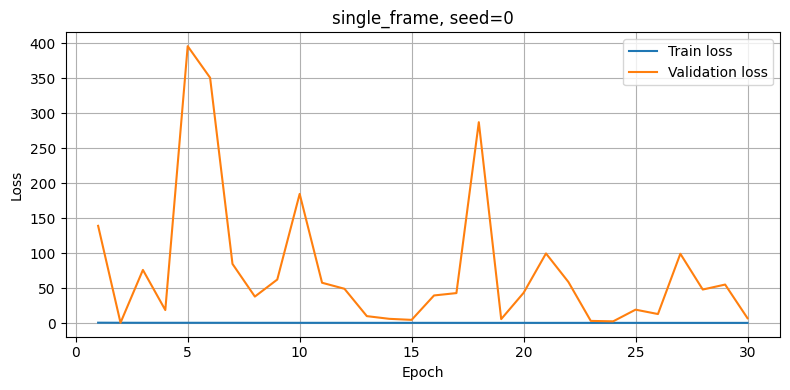

Saved: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_SingleFrame_SpatialOnly_NoLS_Seed0_v1/single_frame/seed_0/loss_curve.png


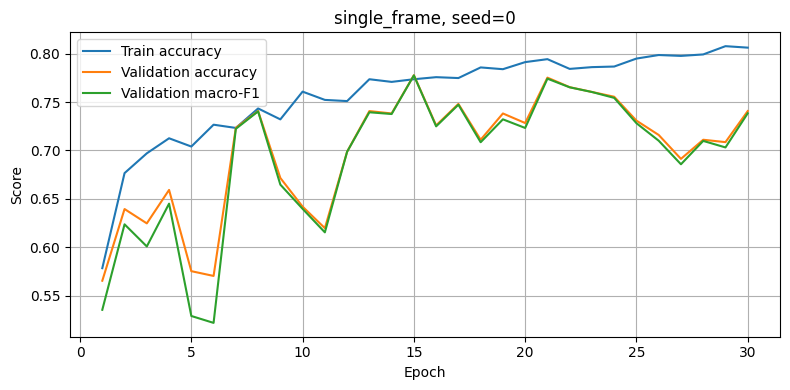

Saved: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_SingleFrame_SpatialOnly_NoLS_Seed0_v1/single_frame/seed_0/score_curve.png
✅ SingleFrame spatial-only selesai untuk RUN_SEED=0


In [13]:
VARIANT_TO_RUN = "single_frame"
variants_to_run = [VARIANT_TO_RUN]

all_run_metrics = []

for seed in SEEDS:  # SEEDS selalu berisi tepat satu nilai: [RUN_SEED]
    result_df = run_experiment(
        variant=VARIANT_TO_RUN,
        seed=seed,
    )
    all_run_metrics.append(result_df)

print(f"✅ SingleFrame spatial-only selesai untuk RUN_SEED={RUN_SEED}")


## 8. Ringkasan hasil seed aktif

Karena notebook ini menjalankan satu seed per session, file ringkasan di folder ini hanya merepresentasikan `RUN_SEED` aktif. **Mean ± std tiga seed jangan dihitung dari satu notebook ini.**

Setelah seed 0, 42, dan 123 selesai, gabungkan ketiga `test_metrics.csv`/prediction outputs secara terpisah untuk membuat tabel mean ± std final.


In [14]:

def load_all_completed_metrics() -> pd.DataFrame:
    frames = []
    variants = list(REQUIRED_VARIANTS)
    for variant in variants:
        for seed in SEEDS:
            path = OUTPUT_DIR / variant / f"seed_{seed}" / "test_metrics.csv"
            if path.exists():
                frames.append(pd.read_csv(path))
            else:
                print("Missing:", path)

    if not frames:
        raise RuntimeError("Belum ada test_metrics.csv yang selesai.")
    return pd.concat(frames, ignore_index=True)

all_metrics_df = load_all_completed_metrics()
all_metrics_df.to_csv(OUTPUT_DIR / "all_seed_metrics.csv", index=False)

aggregate_columns = [
    "accuracy",
    "balanced_accuracy",
    "f1_macro",
    "precision_violence",
    "recall_violence",
    "f1_violence",
    "roc_auc",
    "average_precision",
]

summary_df = (
    all_metrics_df
    .groupby(["variant", "dataset"])[aggregate_columns]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)
summary_df.columns = [
    "_".join([str(part) for part in col if str(part)])
    if isinstance(col, tuple) else col
    for col in summary_df.columns
]
# Pisahkan hasil in-domain (6 benchmark + pooled) dari domain held-out RWF
summary_df.to_csv(OUTPUT_DIR / "summary_mean_std.csv", index=False)

# --- definisikan dulu, sebelum dipakai di mana pun ---
display_columns = [
    "variant", "dataset",
    "accuracy_mean", "accuracy_std",
    "f1_violence_mean", "f1_violence_std",
    "roc_auc_mean", "roc_auc_std",
    "average_precision_mean", "average_precision_std",
]
available_display = [c for c in display_columns if c in summary_df.columns]

# --- hasil in-domain: 6 benchmark + ALL_TESTS_POOLED ---
indomain_df = summary_df[summary_df["dataset"] != "RWF"]
indomain_df.to_csv(OUTPUT_DIR / "summary_indomain.csv", index=False)
print("=== IN-DOMAIN (6 benchmark + pooled 411) ===")
display(indomain_df[available_display].round(4))

# --- domain held-out: RWF-2000 ---
heldout_df = summary_df[summary_df["dataset"] == "RWF"]
if not heldout_df.empty:
    heldout_df.to_csv(OUTPUT_DIR / "summary_heldout_rwf.csv", index=False)
    print("\n=== HELD-OUT DOMAIN: RWF-2000 ===")
    display(heldout_df[available_display].round(4))
else:
    print("\n[!] Baris RWF tidak ditemukan — cek TEST_SPECS dan cache RWF.")


=== IN-DOMAIN (6 benchmark + pooled 411) ===


,variant,dataset,accuracy_mean,accuracy_std,f1_violence_mean,f1_violence_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
0,single_frame,ALL_TESTS_POOLED,0.7956,NaN,0.7889,NaN,0.8791,NaN,0.8583,NaN
1,single_frame,AVDV,0.6857,NaN,0.8070,NaN,0.6123,NaN,0.7769,NaN
2,single_frame,HF,0.9500,NaN,0.9495,NaN,0.9744,NaN,0.9828,NaN
3,single_frame,MF,0.8500,NaN,0.8421,NaN,0.9200,NaN,0.8988,NaN
4,single_frame,RLVS,0.7800,NaN,0.7500,NaN,0.8676,NaN,0.8316,NaN
6,single_frame,SCFD,0.6000,NaN,0.5000,NaN,0.5467,NaN,0.5470,NaN
7,single_frame,VCF,0.6538,NaN,0.6087,NaN,0.7751,NaN,0.7028,NaN



=== HELD-OUT DOMAIN: RWF-2000 ===


,variant,dataset,accuracy_mean,accuracy_std,f1_violence_mean,f1_violence_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
5,single_frame,RWF,0.5581,NaN,0.4117,NaN,0.5746,NaN,0.5842,NaN


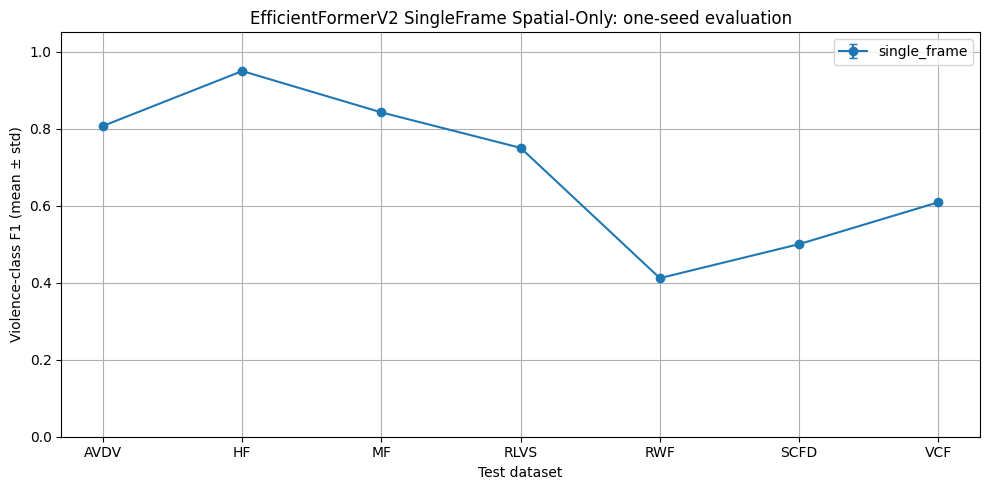

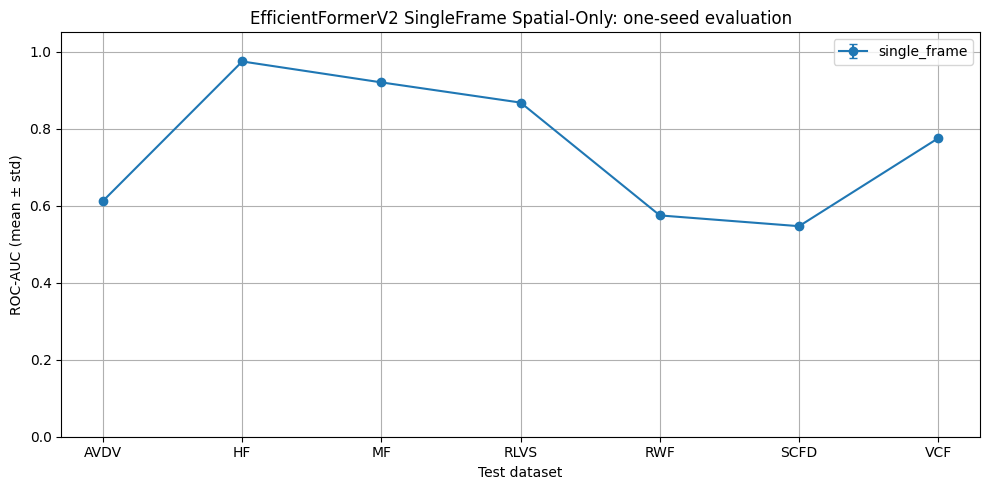

In [15]:

# Visualisasi ringkas performa.
plot_data = (
    all_metrics_df[all_metrics_df["dataset"] != "ALL_TESTS_POOLED"]
    .groupby(["variant", "dataset"], as_index=False)
    .agg(
        f1_violence_mean=("f1_violence", "mean"),
        f1_violence_std=("f1_violence", "std"),
        auc_mean=("roc_auc", "mean"),
        auc_std=("roc_auc", "std"),
    )
)

fig, ax = plt.subplots(figsize=(10, 5))
for variant, frame in plot_data.groupby("variant"):
    ax.errorbar(
        frame["dataset"],
        frame["f1_violence_mean"],
        yerr=frame["f1_violence_std"],
        marker="o",
        capsize=3,
        label=variant,
    )
ax.set_ylim(0, 1.05)
ax.set_ylabel("Violence-class F1 (mean ± std)")
ax.set_xlabel("Test dataset")
ax.set_title("EfficientFormerV2 SingleFrame Spatial-Only: one-seed evaluation")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "aggregate_f1_violence.png", dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for variant, frame in plot_data.groupby("variant"):
    ax.errorbar(
        frame["dataset"],
        frame["auc_mean"],
        yerr=frame["auc_std"],
        marker="o",
        capsize=3,
        label=variant,
    )
ax.set_ylim(0, 1.05)
ax.set_ylabel("ROC-AUC (mean ± std)")
ax.set_xlabel("Test dataset")
ax.set_title("EfficientFormerV2 SingleFrame Spatial-Only: one-seed evaluation")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "aggregate_roc_auc.png", dpi=200)
plt.show()


## 9. Model complexity dan latency perangkat saat ini

Pengukuran memakai perangkat runtime saat notebook dijalankan.

- Input model: `1 × 1 × 3 × 64 × 64`.
- Hanya **satu frame** yang di-upsample ke 224×224 dan diproses EfficientFormerV2-S0.
- Tidak ada BiLSTM, temporal attention, TSM, atau temporal pooling.
- Parameter count seharusnya sama dengan FrameMean bila classifier identik, tetapi compute backbone jauh lebih kecil karena backbone hanya dipanggil untuk satu frame.
- Latency memakai warm-up, sinkronisasi CUDA jika diperlukan, P50/P90/P95/P99, mean, dan standard deviation.
- `ptflops` dilaporkan sebagai MACs sesuai keluaran pustaka.

**Catatan fairness:** latency di sini adalah *model inference latency* dan tidak memasukkan biaya decoding video. Gunakan definisi yang sama ketika membandingkan dengan model lain.


In [16]:

def synchronize_device():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()


@torch.inference_mode()
def benchmark_model_latency(
    model: nn.Module,
    warmup: int = LATENCY_WARMUP,
    runs: int = LATENCY_RUNS,
) -> Dict[str, float]:
    model.eval()

    dummy = torch.randn(
        1,
        MODEL_INPUT_FRAMES,
        3,
        RAW_HEIGHT,
        RAW_WIDTH,
        device=DEVICE,
    )

    # Warm-up.
    for _ in range(warmup):
        _ = model(dummy)

    synchronize_device()

    times_ms = []

    for _ in range(runs):
        synchronize_device()
        start = time.perf_counter()

        _ = model(dummy)

        synchronize_device()
        elapsed_ms = (time.perf_counter() - start) * 1000.0
        times_ms.append(elapsed_ms)

    times_ms = np.asarray(times_ms, dtype=np.float64)

    return {
        "latency_mean_ms": float(times_ms.mean()),
        "latency_std_ms": float(times_ms.std(ddof=0)),
        "latency_p50_ms": float(np.percentile(times_ms, 50)),
        "latency_p90_ms": float(np.percentile(times_ms, 90)),
        "latency_p95_ms": float(np.percentile(times_ms, 95)),
        "latency_p99_ms": float(np.percentile(times_ms, 99)),
    }


def benchmark_completed_model(
    variant: str,
    seed: int,
) -> Dict[str, object]:
    checkpoint_path = (
        OUTPUT_DIR
        / variant
        / f"seed_{seed}"
        / "best.pt"
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(checkpoint_path)

    set_global_seed(seed)

    model = EfficientFormerSingleFrame(
        variant=variant,
        pretrained=False,
    ).to(DEVICE)

    checkpoint = safe_torch_load(
        checkpoint_path,
        map_location=DEVICE,
    )

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    total_params, trainable_params = count_parameters(model)

    result = {
        "variant": variant,
        "seed_checkpoint": seed,
        "device": str(DEVICE),
        "device_name": (
            torch.cuda.get_device_name(0)
            if DEVICE.type == "cuda"
            else platform.processor()
        ),
        "total_parameters": total_params,
        "trainable_parameters": trainable_params,
        "input_shape": [1, MODEL_INPUT_FRAMES, 3, RAW_HEIGHT, RAW_WIDTH],
        "backbone_internal_resolution": [
            BACKBONE_INPUT_SIZE,
            BACKBONE_INPUT_SIZE,
        ],
        "uses_bilstm": False,
        "uses_temporal_attention": False,
        "temporal_aggregation": "none",
        "frame_selection_policy": "fixed_middle_sample_earlier_tie",
        "single_frame_index_0based": SINGLE_FRAME_INDEX,
        "single_frame_number_1based": SINGLE_FRAME_NUMBER_1BASED,
        "label_smoothing": 0.0,
    }

    result.update(benchmark_model_latency(model))

    try:
        from ptflops import get_model_complexity_info

        macs, params = get_model_complexity_info(
            model,
            (MODEL_INPUT_FRAMES, 3, RAW_HEIGHT, RAW_WIDTH),
            as_strings=False,
            print_per_layer_stat=False,
            verbose=False,
        )

        result["ptflops_macs"] = float(macs)
        result["ptflops_gmacs"] = float(macs / 1e9)
        result["ptflops_parameters"] = float(params)

    except Exception as error:
        result["ptflops_error"] = repr(error)

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


# Audit checkpoint yang akan dipakai.
VARIANT_TO_RUN = "single_frame"
variants_to_run = [VARIANT_TO_RUN]
BENCHMARK_SEED = SEEDS[0]

run_dir = (
    OUTPUT_DIR
    / VARIANT_TO_RUN
    / f"seed_{BENCHMARK_SEED}"
)

files_to_check = {
    "best checkpoint": run_dir / "best.pt",
    "last checkpoint": run_dir / "last.pt",
    "training history": run_dir / "history.csv",
    "test metrics": run_dir / "test_metrics.csv",
    "completion marker": run_dir / "completed.json",
}

print("Run directory:", run_dir)
print()

for name, path in files_to_check.items():
    print(f"{name:20s}: {path.exists()} | {path}")


Run directory: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_SingleFrame_SpatialOnly_NoLS_Seed0_v1/single_frame/seed_0

best checkpoint     : True | /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_SingleFrame_SpatialOnly_NoLS_Seed0_v1/single_frame/seed_0/best.pt
last checkpoint     : True | /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_SingleFrame_SpatialOnly_NoLS_Seed0_v1/single_frame/seed_0/last.pt
training history    : True | /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_SingleFrame_SpatialOnly_NoLS_Seed0_v1/single_frame/seed_0/history.csv
test metrics        : True | /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_SingleFrame_SpatialOnly_NoLS_Seed0_v1/single_frame/seed_0/test_metrics.csv
completion marker   : True | /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_SingleFrame_SpatialOnly_NoLS_Seed0_v1/single_frame/seed_0/co

In [17]:
VARIANT_TO_RUN = "single_frame"
variants_to_run = [VARIANT_TO_RUN]
BENCHMARK_SEED = SEEDS[0]

benchmark_rows = []

for variant in variants_to_run:
    checkpoint_path = (
        OUTPUT_DIR
        / variant
        / f"seed_{BENCHMARK_SEED}"
        / "best.pt"
    )

    print("Checkpoint yang dicari:", checkpoint_path)
    print("Checkpoint tersedia:", checkpoint_path.exists())

    if not checkpoint_path.exists():
        print(
            f"⚠️ Benchmark dilewati karena best.pt seed "
            f"{BENCHMARK_SEED} tidak ditemukan."
        )
        continue

    benchmark_rows.append(
        benchmark_completed_model(
            variant=variant,
            seed=BENCHMARK_SEED,
        )
    )

if benchmark_rows:
    benchmark_df = pd.DataFrame(benchmark_rows)

    benchmark_output = (
        OUTPUT_DIR
        / f"efficiency_benchmark_{VARIANT_TO_RUN}"
          f"_seed_{BENCHMARK_SEED}.csv"
    )

    benchmark_df.to_csv(
        benchmark_output,
        index=False,
    )

    display(benchmark_df.T)
    print("Saved:", benchmark_output)
else:
    print("Tidak ada checkpoint yang berhasil dibenchmark.")


Checkpoint yang dicari: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_SingleFrame_SpatialOnly_NoLS_Seed0_v1/single_frame/seed_0/best.pt
Checkpoint tersedia: True


,0
variant,single_frame
seed_checkpoint,0
device,cuda
device_name,NVIDIA A100-SXM4-40GB
total_parameters,3334866
trainable_parameters,3334866
input_shape,"[1, 1, 3, 64, 64]"
backbone_internal_resolution,"[224, 224]"
uses_bilstm,False
uses_temporal_attention,False


Saved: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_SingleFrame_SpatialOnly_NoLS_Seed0_v1/efficiency_benchmark_single_frame_seed_0.csv


## 10. Paket hasil

Folder output berisi:
- best dan last checkpoint untuk seed aktif;
- `config.json` yang merekam frame-selection policy;
- `history.csv` dan training curves;
- prediksi per test dataset;
- confusion matrix dan ROC curve;
- bootstrap confidence interval;
- tabel hasil seed aktif;
- benchmark parameter/MACs/latency;
- arsip ZIP seluruh hasil.


In [18]:

archive_base = str(OUTPUT_DIR.parent / f"{OUTPUT_DIR.name}_results")
archive_path = shutil.make_archive(archive_base, "zip", root_dir=OUTPUT_DIR)
print("Archive created:", archive_path)
print("Semua hasil juga tetap tersimpan di:", OUTPUT_DIR)


Archive created: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_SingleFrame_SpatialOnly_NoLS_Seed0_v1_results.zip
Semua hasil juga tetap tersimpan di: /content/drive/MyDrive/IVS/ViolenceDetection/Models/EffTempNet/EffTempNet_SingleFrame_SpatialOnly_NoLS_Seed0_v1
